After running the cell above and authenticating, your Google Drive will be mounted at `/content/drive`. Now, I will load the `u.data` and `u.items` datasets from your 'ai' folder within 'colab notebooks'.

In [6]:
import pandas as pd

# Define column names for u.data based on typical MovieLens format
u_data_cols = ['user_id', 'item_id', 'rating', 'timestamp']

# Define column names for u.items based on typical MovieLens format
u_items_cols = ['item_id', 'movie_title', 'release_date', 'video_release_date', 'IMDb_URL', 'unknown', 'Action', 'Adventure', 'Animation', 'Childrens', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

# Construct the full paths to the files
u_data_path = 'u.data'
u_items_path = 'u.item'

# Load u.data
try:
    u_data_df = pd.read_csv(u_data_path, sep='\t', names=u_data_cols, encoding='latin-1')
    print("u.data loaded successfully!")
    display(u_data_df.head())
except FileNotFoundError:
    print(f"Error: u.data not found at {u_data_path}. Please check the path and file name.")
except Exception as e:
    print(f"Error loading u.data: {e}")

print("\n" + "-"*30 + "\n") # Separator for better readability

# Load u.items
try:
    u_items_df = pd.read_csv(u_items_path, sep='|', names=u_items_cols, encoding='latin-1')
    print("u.items loaded successfully!")
    display(u_items_df.head())
except FileNotFoundError:
    print(f"Error: u.items not found at {u_items_path}. Please check the path and file name.")
except Exception as e:
    print(f"Error loading u.items: {e}")

u.data loaded successfully!


,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596



------------------------------

u.items loaded successfully!


,item_id,movie_title,release_date,video_release_date,IMDb_URL,unknown,Action,Adventure,Animation,Childrens,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


Now, let's create the user-item matrix where rows are `user_id`, columns are `item_id`, and values are `rating`. Missing values will be `NaN`.

In [7]:
# Create the user-item matrix
user_item_matrix = u_data_df.pivot_table(index='user_id', columns='item_id', values='rating')

print("User-Item Matrix created successfully!")
display(user_item_matrix.head())

User-Item Matrix created successfully!


item_id,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
user_id,,,,,,,,,,,,,,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0,5.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Now, let's visualize the user-item matrix as a heatmap. We'll use a specific color for the missing values (`NaN`s) to distinguish them from the actual ratings.

Let's examine the sparsity of your user-item matrix. A sparse matrix contains many zero or `NaN` values, which is typical for recommendation systems where users only interact with a small subset of available items.

In [8]:
# Get the shape of the user-item matrix
num_users, num_items = user_item_matrix.shape
print(f"Shape of user-item matrix: {num_users} users x {num_items} items")

# Count the number of non-NaN ratings
num_ratings = user_item_matrix.count().sum()
print(f"Number of actual ratings: {num_ratings}")

# Calculate sparsity
total_possible_ratings = num_users * num_items
sparsity = (1 - (num_ratings / total_possible_ratings)) * 100
print(f"Matrix Sparsity: {sparsity:.2f}%")

if sparsity > 90:
    print("\nThis high sparsity is why your heatmap might appear mostly gray. Most cells represent missing values.")

# To better visualize the colors, let's look at a smaller subset of the matrix.
# For example, the first 50 users and first 50 items.
print("\nDisplaying a heatmap for a subset (first 50 users, first 50 items) for better visibility:")

matrix_subset = user_item_matrix.iloc[:50, :50].fillna(0)

plt.figure(figsize=(10, 8))
sns.heatmap(matrix_subset, cmap=cmap, norm=norm, linewidths=0.01, linecolor='lightgray', cbar_kws={'ticks': [0, 1, 2, 3, 4, 5]})

plt.title('User-Item Matrix Heatmap (Subset: First 50 Users & Items)', fontsize=14)
plt.xlabel('Movie ID', fontsize=10)
plt.ylabel('User ID', fontsize=10)

cbar = plt.gca().collections[0].colorbar
cbar.set_ticklabels(['NaN', '1', '2', '3', '4', '5'])

plt.tight_layout()
plt.show()

Shape of user-item matrix: 943 users x 1682 items
Number of actual ratings: 100000
Matrix Sparsity: 93.70%

This high sparsity is why your heatmap might appear mostly gray. Most cells represent missing values.

Displaying a heatmap for a subset (first 50 users, first 50 items) for better visibility:


NameError: name 'cmap' is not defined

<Figure size 1000x800 with 0 Axes>

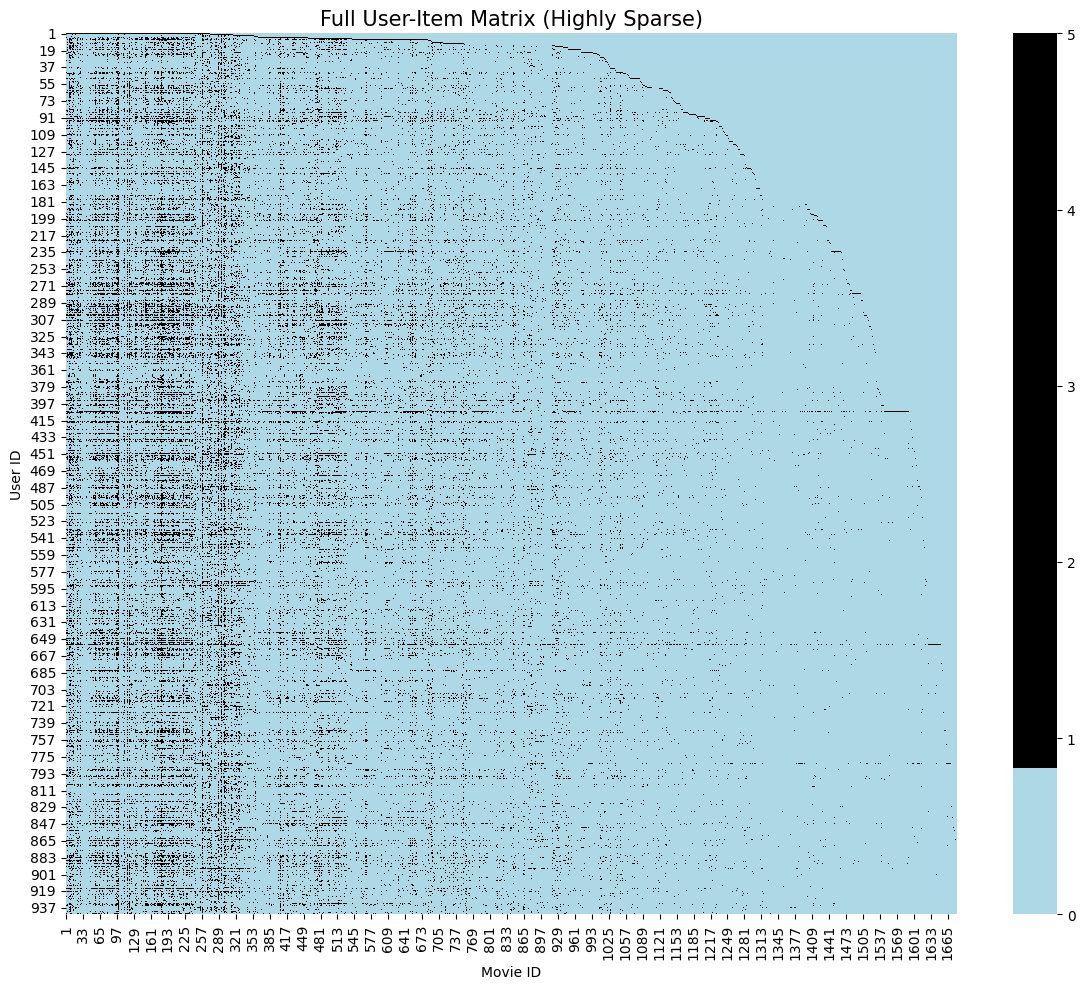

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import ListedColormap

# 1. Define the Color Scheme
nan_color = 'lightblue'
rating_colors = 'black' # 1-5 stars
colors_list = [nan_color] + [rating_colors]*5
cmap = ListedColormap(colors_list)
norm = plt.Normalize(vmin=0, vmax=5)

# 2. Prepare Data
# High sparsity (93.7%) means most of the matrix is NaN.
full_matrix_filled = user_item_matrix.fillna(0)

# 3. Plotting
plt.figure(figsize=(12, 10))

# Full Matrix Heatmap
sns.heatmap(full_matrix_filled, cmap=cmap, norm=norm, cbar=True)
plt.title('Full User-Item Matrix (Highly Sparse)', fontsize=15)
plt.xlabel('Movie ID')
plt.ylabel('User ID')

# Customize colorbar ticks
cbar = plt.gca().collections[0].colorbar

plt.tight_layout()
plt.show()

### Calculating Mean Ratings Per User

We will now compute the average rating given by each user. This is a common step in normalization for recommendation systems.

In [ ]:
# Calculate mean rating per user (ignoring NaNs)
user_mean_ratings = user_item_matrix.mean(axis=1)

print("Mean ratings per user calculated and saved to 'user_mean_ratings'.")
print("\nFirst 10 user averages:")
display(user_mean_ratings.head(10))

# Basic stats of the averages
print("\nSummary Statistics of User Means:")
display(user_mean_ratings.describe())

Mean ratings per user calculated and saved to 'user_mean_ratings'.

First 10 user averages:


,0
user_id,
1,3.610294
2,3.709677
3,2.796296
4,4.333333
5,2.874286
6,3.635071
7,3.965261
8,3.796610
9,4.272727



Summary Statistics of User Means:


,0
count,943.000000
mean,3.588191
std,0.445233
min,1.491954
25%,3.323054
50%,3.620690
75%,3.869565
max,4.869565


### Normalizing Ratings (Mean Centering)

We will now subtract the user's mean rating from each of their individual ratings.
* A **positive** value means the user liked the movie more than their average.
* A **negative** value means they liked it less than their average.
* **0** means it matched their average exactly.

In [ ]:
# Subtract the user mean from each rating (aligning along the index/user_id)
normalized_matrix = user_item_matrix.sub(user_mean_ratings, axis=0)

print("Normalized User-Item Matrix (Mean-Centered):")
display(normalized_matrix.head())

# Verification: The mean of each row in the normalized matrix should be close to 0
print("\nVerification - Mean of first 5 rows (should be ~0):")
print(normalized_matrix.mean(axis=1).head())

Normalized User-Item Matrix (Mean-Centered):


item_id,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
user_id,,,,,,,,,,,,,,,,,,,,,
1,1.389706,-0.610294,0.389706,-0.610294,-0.610294,1.389706,0.389706,-2.610294,1.389706,-0.610294,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.290323,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.709677,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1.125714,0.125714,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Verification - Mean of first 5 rows (should be ~0):
user_id
1   -5.224579e-17
2    1.862310e-16
3    1.644775e-17
4    2.960595e-16
5    1.725604e-16
dtype: float64


In [ ]:
!pip install fancyimpute

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 12.2 MB/s eta 0:00:00
  Created wheel for fancyimpute: filename=fancyimpute-0.7.0-py3-none-any.whl size=29879 sha256=6a821658105f3f8c33b45970ee4895d14ab8f47dce216100b4270cd7374b5541
  Stored in directory: /root/.cache/pip/wheels/df/20/91/e4850b9a31cf660c1bc95515d3bcbc8010e869e5de6d5baf07
  Created wheel for knnimpute: filename=knnimpute-0.1.0-py3-none-any.whl size=11331 sha256=484f5584118862da97177d17e2d3da7aef68d16ecc35f8aca8293abbbd7d9862
  Stored in directory: /root/.cache/pip/wheels/89/11/61/aa5a3167bfff49218cd043a73a83034b9eadd858b0059521be
Successfully built fancyimpute knnimpute


### Matrix Completion using SoftImpute

SoftImpute is an iterative algorithm that finds a low-rank matrix fit to the observed entries. It is particularly effective for large, sparse matrices like the MovieLens dataset.

In [ ]:
from fancyimpute import SoftImpute

# Initialize SoftImpute solver
# 'convergence_threshold' and 'max_iters' can be adjusted for speed/accuracy
soft_imputer = SoftImpute(verbose=True)

# Apply SoftImpute to the normalized matrix
# SoftImpute expects a numpy array with NaNs preserved
normalized_matrix_filled_values = soft_imputer.fit_transform(normalized_matrix.values)

# Convert the result back to a DataFrame
soft_imputed_df = pd.DataFrame(normalized_matrix_filled_values,
                               columns=normalized_matrix.columns,
                               index=normalized_matrix.index)

print("SoftImpute Matrix Completion finished.")
display(soft_imputed_df.head())

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[SoftImpute] Max Singular Value of X_init = 81.836389
[SoftImpute] Iter 1: observed MAE=0.094216 rank=756
[SoftImpute] Iter 2: observed MAE=0.092661 rank=671
[SoftImpute] Iter 3: observed MAE=0.091269 rank=616
[SoftImpute] Iter 4: observed MAE=0.090118 rank=576
[SoftImpute] Iter 5: observed MAE=0.089142 rank=545
[SoftImpute] Iter 6: observed MAE=0.088281 rank=520
[SoftImpute] Iter 7: observed MAE=0.087538 rank=498
[SoftImpute] Iter 8: observed MAE=0.086892 rank=480
[SoftImpute] Iter 9: observed MAE=0.086324 rank=464
[SoftImpute] Iter 10: observed MAE=0.085805 rank=451
[SoftImpute] Iter 11: observed MAE=0.085327 rank=437
[SoftImpute] Iter 12: observed MAE=0.084892 rank=426
[SoftImpute] Iter 13: observed MAE=0.084512 rank=415
[SoftImpute] Iter 14: observed MAE=0.084185 rank=407
[SoftImpute] Iter 15: observed MAE=0.083890 rank=399
[SoftImpute] Iter 16: observed MAE=0.083596 rank=390
[SoftImpute] Iter 17: observed MAE=0.083323 rank=383
[SoftImpute] Iter 18: observed MAE=0.083073 rank=377
[

item_id,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
user_id,,,,,,,,,,,,,,,,,,,,,
1,1.389706,-0.610294,0.389706,-0.610294,-0.610294,1.389706,0.389706,-2.610294,1.389706,-0.610294,...,-0.009012,0.000772,-0.002862,-0.009094,0.000359,-0.127051,-0.007276,-0.067164,0.000367,-0.033536
2,0.290323,-0.259869,-0.237993,-0.218511,0.023825,0.257819,-0.178900,0.208781,0.168280,-1.709677,...,-0.025339,0.005829,-0.011764,-0.037375,-0.002098,-0.019060,-0.001092,-0.010076,0.000616,-0.001818
3,-0.083021,-0.001826,0.000688,-0.426413,-0.190003,0.127280,0.177836,0.249214,0.410574,-0.411152,...,0.032224,-0.001082,-0.036954,-0.117407,-0.000443,-0.016909,-0.000968,-0.008939,-0.000222,-0.009884
4,0.079635,-0.007031,0.045588,-0.317237,0.089636,0.022562,0.121840,0.221754,-0.519594,0.171112,...,0.082360,-0.004134,0.002203,0.007000,-0.008463,0.012487,0.000715,0.006601,0.000838,-0.005272
5,1.125714,0.125714,-0.500448,0.450619,-0.013533,-0.120169,1.273059,0.237088,0.158638,-0.248432,...,0.144784,-0.003277,-0.017562,-0.055796,-0.012741,-0.052999,-0.003035,-0.028017,0.000683,0.023576


### Final Reconstructed Ratings
We add the user means back to the SoftImpute results to recover the predicted star ratings (1-5).

In [ ]:
# Denormalize
final_soft_predictions = soft_imputed_df.add(user_mean_ratings, axis=0)

print("Final Predicted Ratings (SoftImpute):")
display(final_soft_predictions.head())

Final Predicted Ratings (SoftImpute):


item_id,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
user_id,,,,,,,,,,,,,,,,,,,,,
1,5.000000,3.000000,4.000000,3.000000,3.000000,5.000000,4.000000,1.000000,5.000000,3.000000,...,3.601282,3.611066,3.607432,3.601200,3.610653,3.483243,3.603018,3.543131,3.610661,3.576758
2,4.000000,3.449808,3.471684,3.491167,3.733502,3.967496,3.530777,3.918459,3.877957,2.000000,...,3.684339,3.715506,3.697913,3.672302,3.707580,3.690618,3.708586,3.699602,3.710293,3.707860
3,2.713276,2.794470,2.796984,2.369883,2.606293,2.923576,2.974133,3.045511,3.206870,2.385144,...,2.828520,2.795214,2.759342,2.678889,2.795854,2.779387,2.795328,2.787358,2.796074,2.786412
4,4.412968,4.326302,4.378921,4.016096,4.422969,4.355896,4.455173,4.555087,3.813739,4.504445,...,4.415694,4.329199,4.335537,4.340333,4.324870,4.345820,4.334048,4.339934,4.334171,4.328061
5,4.000000,3.000000,2.373838,3.324905,2.860753,2.754117,4.147345,3.111374,3.032924,2.625854,...,3.019070,2.871009,2.856724,2.818489,2.861545,2.821286,2.871251,2.846268,2.874968,2.897862


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'preds' is the variable where you saved svd.test(testset)
# Calculate the error: Predicted Rating (est) minus Actual Rating (r_ui)
errors = [prediction.est - prediction.r_ui for prediction in preds]

# Set up the plot
plt.figure(figsize=(10, 6))
sns.histplot(errors, bins=50, kde=True, color='teal')

# Add labels and a red line at 0 (Perfect Prediction)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Perfect Prediction (0 Error)')
plt.title('Distribution of Prediction Errors', fontsize=14)
plt.xlabel('Error (Predicted Rating - Actual Rating)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

NameError: name 'preds' is not defined

In [ ]:
from surprise import SVD
from surprise import accuracy

# 1. Aplicar matrix completion (usando Singular Value Decomposition)
# Asumiendo que ya tienes tu 'trainset' y 'testset' creados
modelo_svd = SVD(n_factors=100, random_state=42)
modelo_svd.fit(trainset)

# 2. Evaluar la reconstrucción en los ratings escondidos
print("Evaluando el modelo en el conjunto de prueba (Hidden Ratings):")
predicciones = modelo_svd.test(testset)

# Calculamos el error
rmse = accuracy.rmse(predicciones)
mae = accuracy.mae(predicciones)

In [ ]:
import random
import pandas as pd

# 1. Escoger usuario (aleatorio)
todos_los_usuarios = ratings['userId'].unique()
usuario_objetivo = random.choice(todos_los_usuarios)
print(f"🎬 Generando recomendaciones para el Usuario Aleatorio ID: {usuario_objetivo}\n")

# 2. Ignorar items con rating previo
# Obtenemos todas las películas y las que el usuario ya calificó
todas_las_peliculas = movies['movieId'].unique()
peliculas_vistas = ratings[ratings['userId'] == usuario_objetivo]['movieId'].unique()

# Filtramos para quedarnos solo con las que NO ha visto
peliculas_no_vistas = [pelicula for pelicula en todas_las_peliculas if pelicula not in peliculas_vistas]

# 3. Predecir los ratings para las películas ignoradas
ratings_predichos = []
for movie_id in peliculas_no_vistas:
    # Predecimos el rating (usamos .est para sacar el valor estimado)
    prediccion = modelo_svd.predict(usuario_objetivo, movie_id).est
    ratings_predichos.append({
        'movieId': movie_id,
        'Rating_Predicho': prediccion
    })

# Convertimos a DataFrame para manipularlo fácilmente
df_predicciones = pd.DataFrame(ratings_predichos)

# 4. Recomendar ratings generados más altos (Top 10)
top_10_recomendaciones = df_predicciones.sort_values(by='Rating_Predicho', ascending=False).head(10)

# 5. Agregar información de título y género de película
# Hacemos un 'merge' (cruce) con el dataframe original de películas
recomendaciones_finales = top_10_recomendaciones.merge(movies, on='movieId', how='left')

# Mostramos el resultado final ordenado y limpio
display(recomendaciones_finales[['title', 'genres', 'Rating_Predicho']])